In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case)

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/00121
00121


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

In [7]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [8]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [9]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1':
    cntrl_vars_init = [1]
elif case[3] == '2':
    cntrl_vars_init = [0,1]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [10]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_' + case + '.pickle'
case_1 = case[0] + case[1] + '0' + case[3] + case[4]
final_file_1 = 'control_' + case_1 + '.pickle'

In [11]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [12]:
# get initial parameters and target states

i_stepsize = 5
i_range = range(0, len(exc),i_stepsize)
i_range_0 = range(0, len(exc),i_stepsize)
i_range_1 = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  5 0.4000000000000001 0.40000000000000013
-------  10 0.4250000000000001 0.42500000000000016
-------  15 0.4500000000000001 0.4500000000000002
-------  20 0.4500000000000001 0.4750000000000002
-------  25 0.4250000000000001 0.5000000000000002
-------  30 0.4250000000000001 0.5250000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  40 0.5250000000000001 0.5500000000000003
-------  45 0.5000000000000002 0.5750000000000003
-------  50 0.47500000000000014 0.6000000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  60 0.5500000000000003 0.6250000000000003
-------  65 0.5000000000000002 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  75 0.5750000000000002 0.6750000000000004
-------  80 0.5250000000000001 0.7000000000000004
-------  85 0.47500000000000014 0.7250000000000004
-------  90 0.6000000000000003 0.7250000000000004
-------  95 0.5250000000000001 0.750000000000000

In [13]:
# get uncontrolled cost

data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  5 0.4000000000000001 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5097.289828199723
Gradient descend method:  None
RUN  0 , total integrated cost =  5097.289828199723
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  10 0.4250000000000001 0.42500000000000016
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9111.456490210901
Gradient descend method:  None
RUN  0 , total integrated cost =  9111.456490210901
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  15 0.4500000000000001 0.4500000000000002

In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    
    if not type(bestControl_init[i]) == type(None):
        continue
        
    control0 = aln.getZeroControl()

    ##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)

    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    with open(init_file,'wb') as f:
        pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

-------  0 0.4000000000000001 0.3500000000000001
-------  5 0.4000000000000001 0.40000000000000013
-------  10 0.4250000000000001 0.42500000000000016
-------  15 0.4500000000000001 0.4500000000000002
-------  20 0.4500000000000001 0.4750000000000002
-------  25 0.4250000000000001 0.5000000000000002
-------  30 0.4250000000000001 0.5250000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  40 0.5250000000000001 0.5500000000000003
-------  45 0.5000000000000002 0.5750000000000003
-------  50 0.47500000000000014 0.6000000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  60 0.5500000000000003 0.6250000000000003
-------  65 0.5000000000000002 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  75 0.5750000000000002 0.6750000000000004
-------  80 0.5250000000000001 0.7000000000000004
-------  85 0.47500000000000014 0.7250000000000004
-------  90 0.6000000000000003 0.7250000000000004
-------  95 0.5250000000000001 0.750000000000000

The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.
--------- 0
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


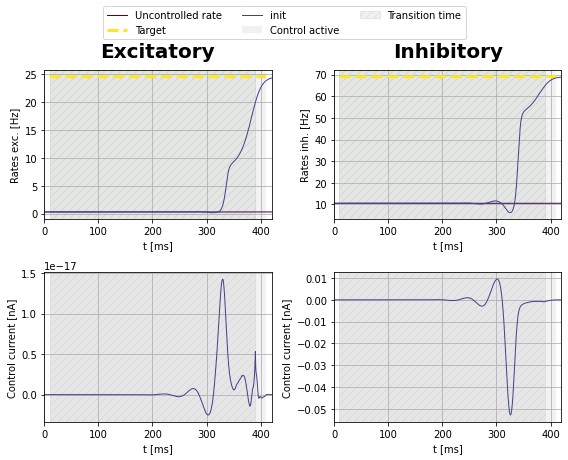

--------- 5
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


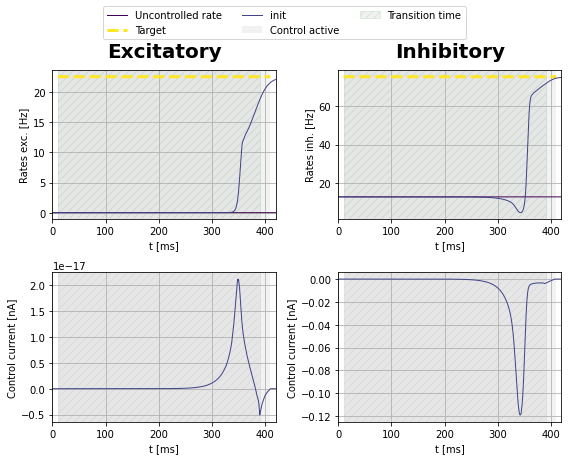

--------- 10
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


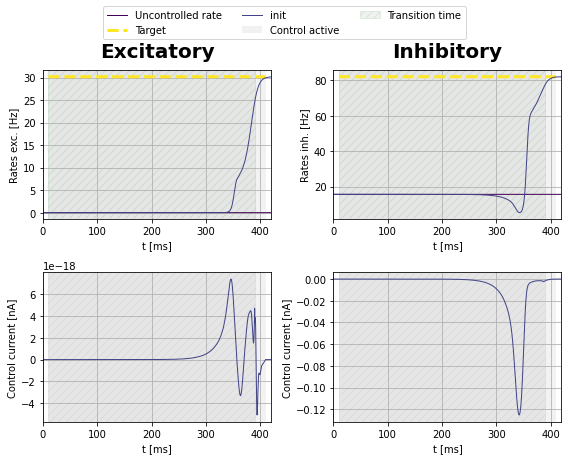

--------- 15
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


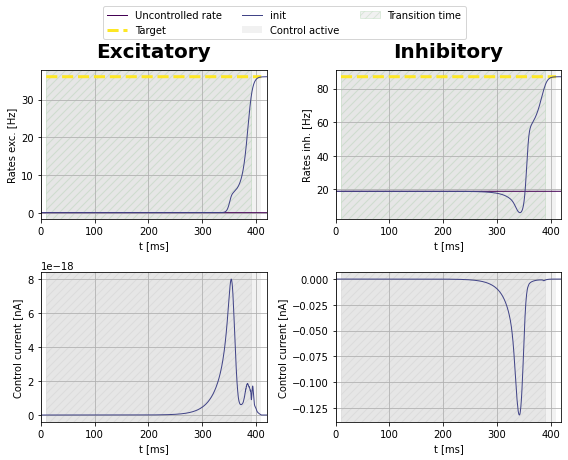

--------- 20
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


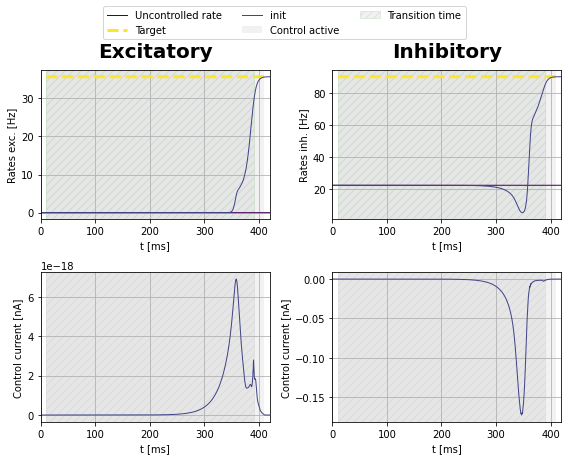

--------- 25
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


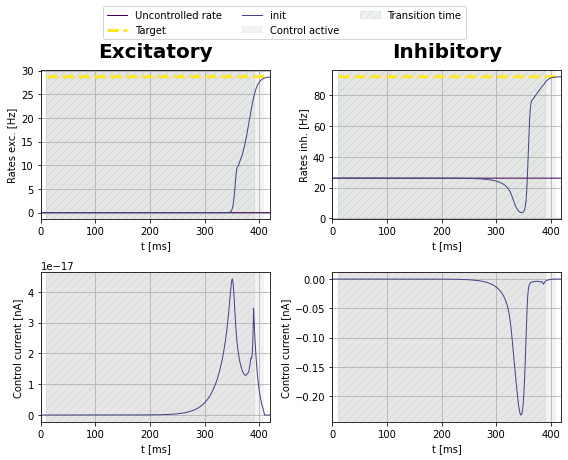

--------- 30
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


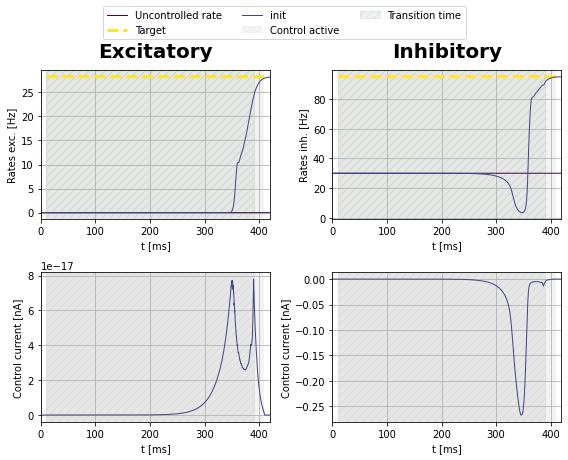

--------- 35
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


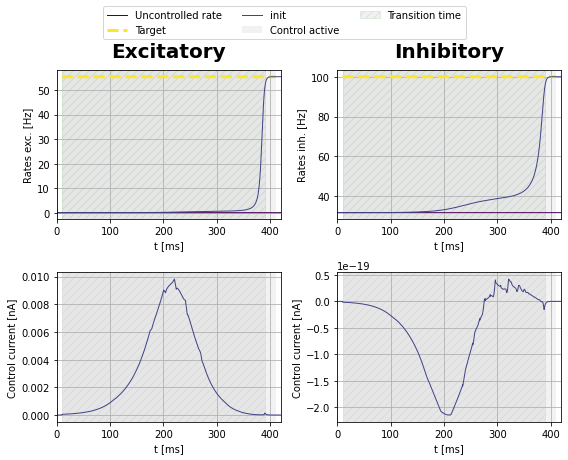

--------- 40
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


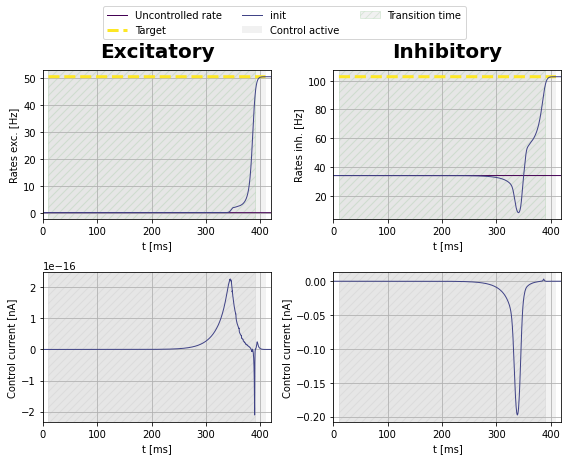

--------- 45
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


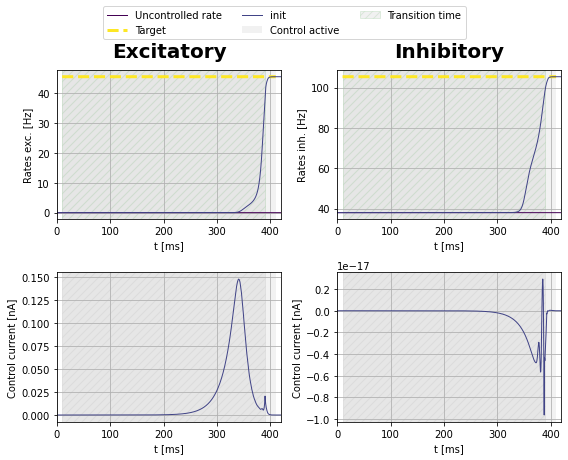

--------- 50
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


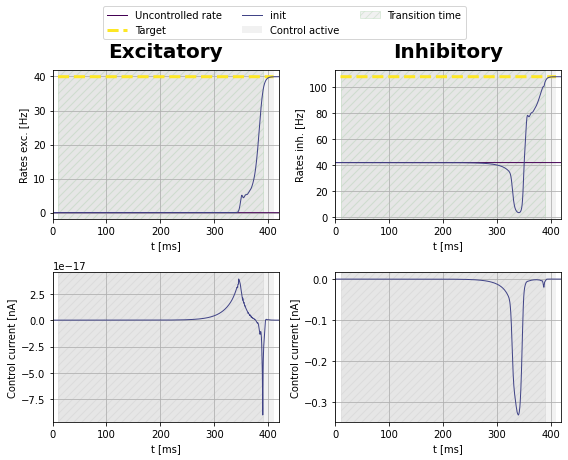

--------- 55
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


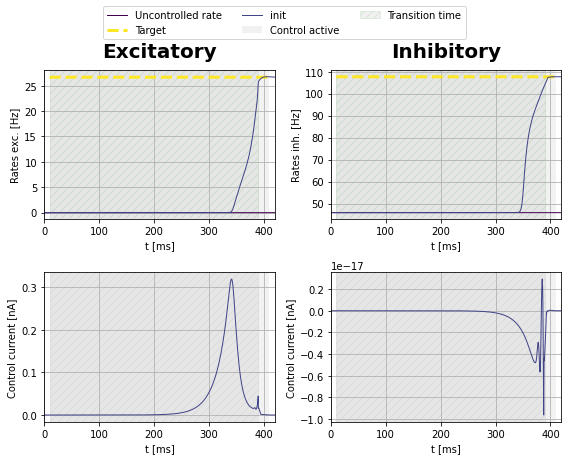

--------- 60
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


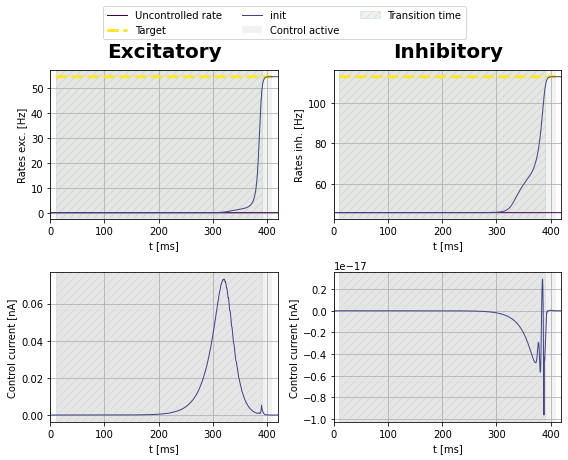

--------- 65
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


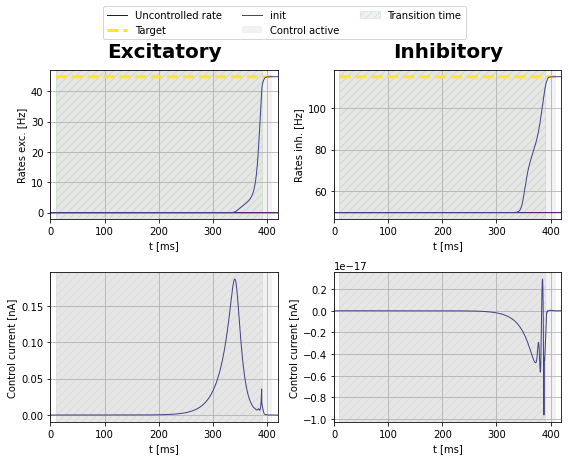

--------- 70
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


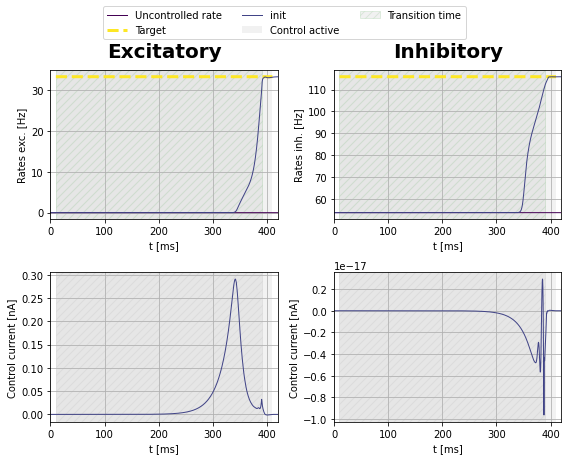

--------- 75
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


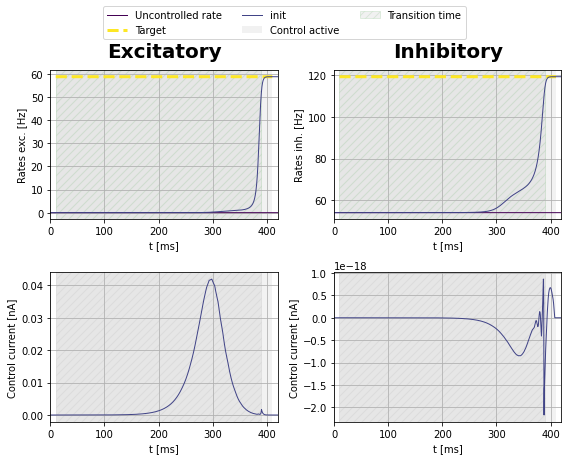

--------- 80
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


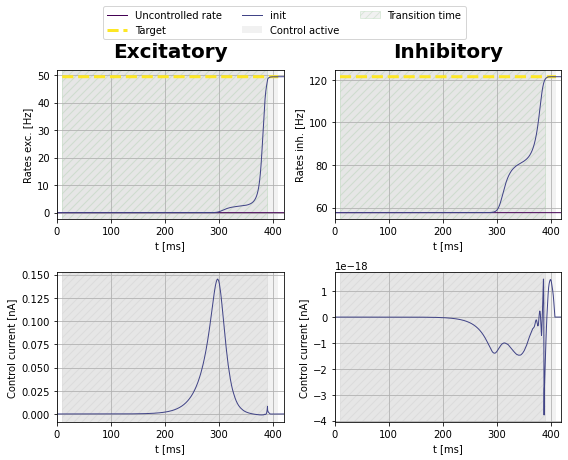

--------- 85
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


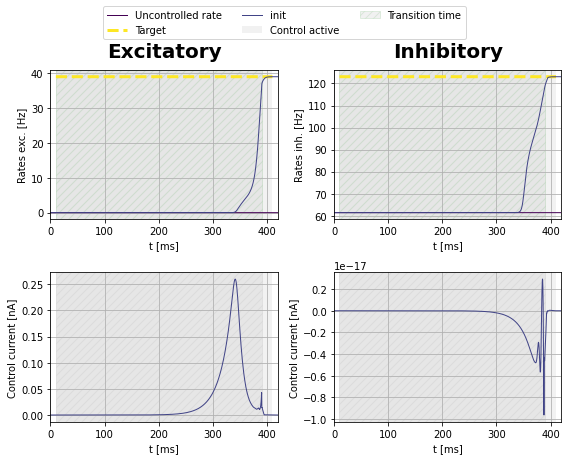

--------- 90
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


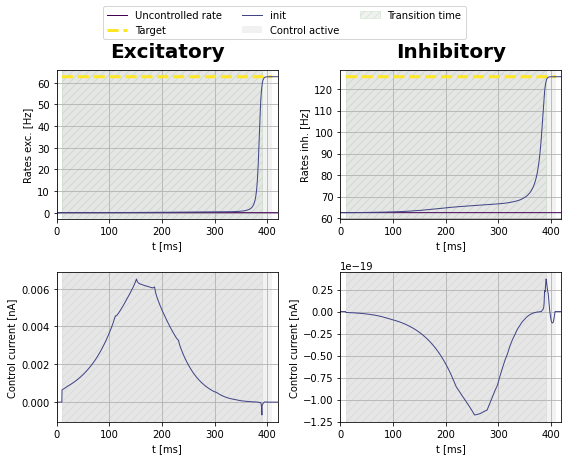

--------- 95
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


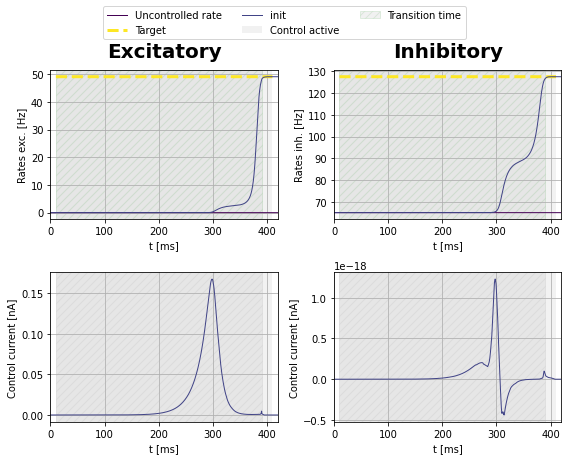

--------- 100
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


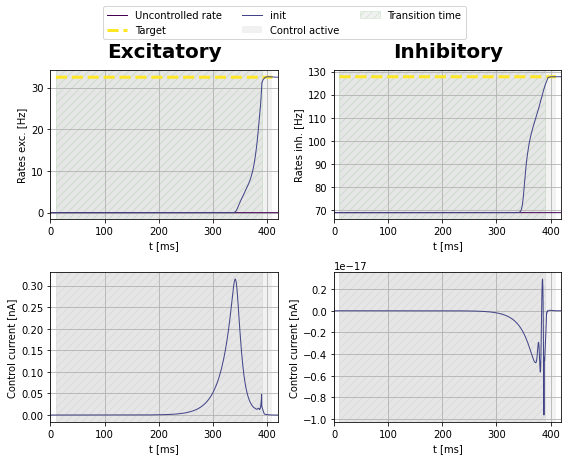

--------- 105
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


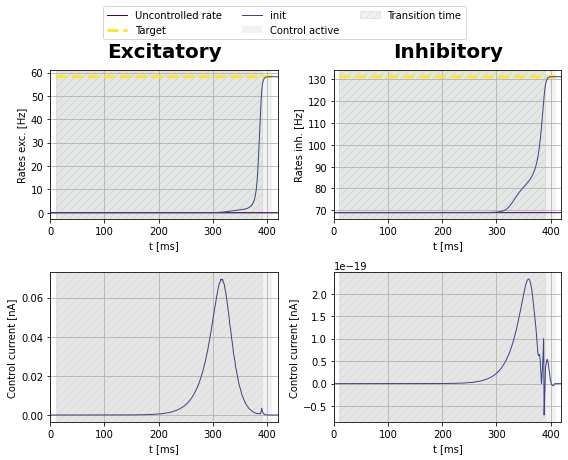

--------- 110
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


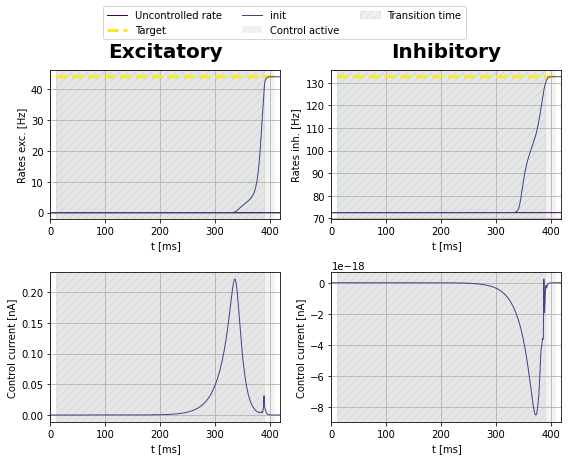

--------- 115
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


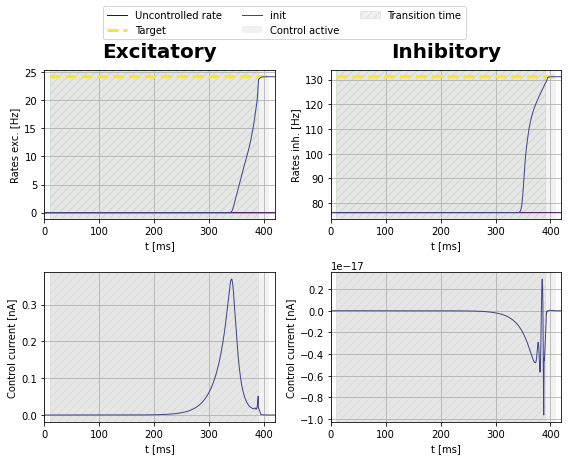

--------- 120
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


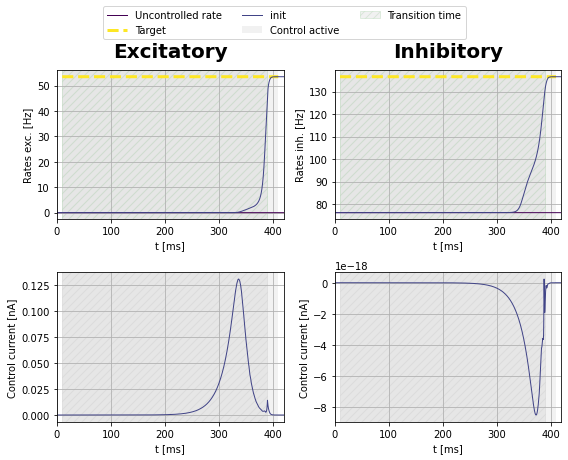

--------- 125
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


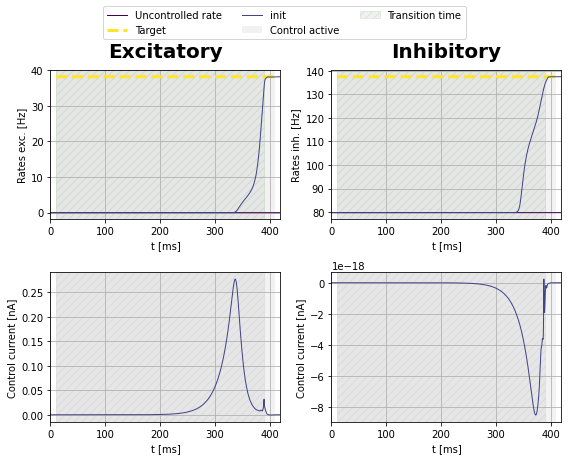

--------- 130
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


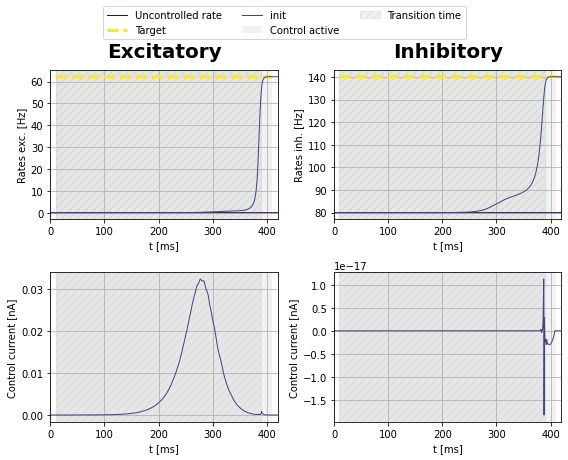

--------- 135
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


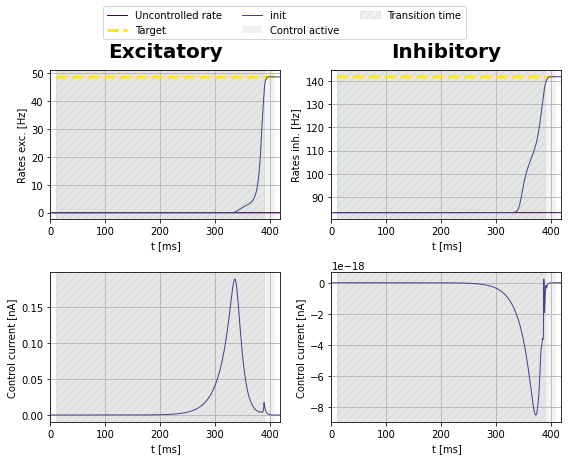

--------- 140
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


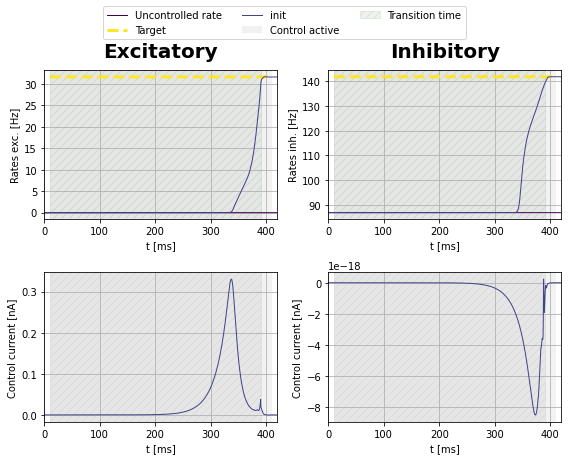

--------- 145
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)


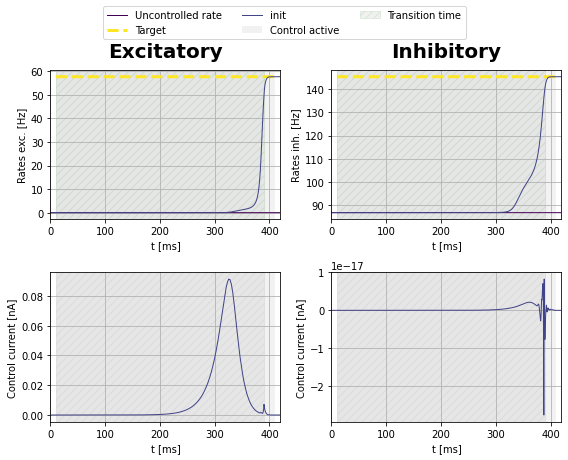

In [15]:

#plot initial guesses
for i in i_range:
    print("---------", i)
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
    plt.show()

In [16]:
found_solution = []
no_solution = []
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break


    for i in i_range:
        print("------- ", i, exc[i], inh[i])    

        if np.abs(np.mean(bestState_init[i][0,0,-300:]) - target[i][0,0,-1]) < 0.1 * np.abs(
            np.mean(bestState_init[i][0,0,-100:]) - bestState_init[i][0,0,0]) and np.abs(
            np.mean(bestState_init[i][0,1,-300:]) - target[i][0,1,-1]) < 0.1 * np.abs(
            np.mean(bestState_init[i][0,1,-100:]) - bestState_init[i][0,1,0]) and np.amax(
            bestState_init[i][0,0,:]) < target[i][0,0,-1] + 5. and np.amax(
            bestState_init[i][0,1,:]) < target[i][0,1,-1] + 5:
            # and np.amin(bestState_init[i][0,0,:]) > bestState_init[i][0,0,0] - 1.
            #and np.amin(bestState_init[i][0,1,:]) > bestState_init[i][0,1,0] - 1.:
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        if len(found_solution) == 0:
            continue
            
        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)
        
        if i == 80.:
            weight_ = 100
            cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)
        
        if i == 95:
            weight_ = 10
            print("weight = ", weight_)
            cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        with open(init_file,'wb') as f:
            pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                         costnode_init, weights_init], f)

------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  5 0.4000000000000001 0.40000000000000013
found solution for  5
-------  10 0.4250000000000001 0.42500000000000016
found solution for  10
-------  15 0.4500000000000001 0.4500000000000002
found solution for  15
-------  20 0.4500000000000001 0.4750000000000002
found solution for  20
-------  25 0.4250000000000001 0.5000000000000002
found solution for  25
-------  30 0.4250000000000001 0.5250000000000002
found solution for  30
-------  35 0.5500000000000003 0.5250000000000002
found solution for  35
-------  40 0.5250000000000001 0.5500000000000003
found solution for  40
-------  45 0.5000000000000002 0.5750000000000003
found solution for  45
-------  50 0.47500000000000014 0.6000000000000003
found solution for  50
-------  55 0.42

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print("------------------------------------------------")
    print('-------------------------', counter)
    
    if counter > 20:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        
        if conv_init[i] == [True, True]:
            continue
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
                       
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        with open(init_file,'wb') as f:
            pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                         costnode_init, weights_init], f)
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
    counter += 1

------------------------------------------------
------------------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
weight =  6059.4981252370435
set cost params:  1.0 0.0 6059.4981252370435
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5901.43256482454
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5901.43256482454
Control only changes marginally.
RUN  1 , total integrated cost =  5901.43256482454
Improved over  1  iterations in  25.862126605585217  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62658281422536 -56.62659089600063
converged for  0
-------  5 0.4000000000000001 0.40000000000000013
weight =  2130.395901000158
set cost params:  1.0 0.0 2130.395901000158
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5094.898301676749
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5094.898301676749
Control only changes marginally.
RUN  1 , total integrated cost =  5094.898301676749
Improved over  1  iterations in  1.0592578947544098  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.625334773778256 -56.62531700956727
converged for  5
-------  10 0.4250000000000001 0.42500000000000016
weight =  3680.3445216974987
set cost params:  1.0 0.0 3680.3445216974987
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9108.981455223953
Gradient descend method:  None


...

RUN  1 , total integrated cost =  23528.052793164294
Control only changes marginally.
RUN  1 , total integrated cost =  23528.052793164294
Improved over  1  iterations in  1.7140857968479395  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.700685702626245 -56.70068528741271
converged for  135
-------  140 0.4500000000000001 0.9000000000000006
weight =  1301.1500863055924
set cost params:  1.0 0.0 1301.1500863055924
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10012.273577251039
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  10012.273577251039
Control only changes marginally.
RUN  1 , total integrated cost =  10012.273577251039
Improved over  1  iterations in  1.6101771965622902  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.651527431527306 -56.65153154112816
converged for  140
-------  145 0.5750000000000002 0.9000000000000006
weight =  13202.325480533325
set cost params:  1.0 0.0 13202.325480533325
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33287.53012848339
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  33287.53012848339
Control only changes marginally.
RUN  1 , total integrated cost =  33287.53012848339
Improved over  1  iterations in  1.6152385007590055  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70354222972624 -56.70354221959676
converged for  145
------------------------------------------------
------------------------- 2
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
full convergence


In [18]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

file found


In [19]:
factor_iteration = 20
conv_0 = [[False]*2] * len(exc)
full_converge = False

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 20:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break
        
    counter += 1
    
    for i in i_range_0:
        print("------- ", i, exc[i], inh[i])
        
        if conv_0[i] == [True, True]:
            continue
            
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

    # exc and inh control current 

        setinit(initVars[i], aln)
        aln.params.duration = dur
        
        if i in [25, 30, 50, 55, 65, 110, 115]:
            bestControl_0[i] = None

        if not type(bestControl_0[i]) == type(None):
            control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
        else:
            control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
            weights_0[i] = weights_init[i]
            cost_0[i] = cost_init[i]

        cgv = None
        max_it = 500 * factor_iteration

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                           + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)
        
        #if i in [25,30]:
        #    weight_ = 10.
        #    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)
        

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        with open(final_file,'wb') as f:
            pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                     costnode_0, weights_0], f)
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
weight =  6059.4981252370435
set cost params:  1.0 0.0 6059.4981252370435
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5901.43256482454
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5901.43256482454
Control only changes marginally.
RUN  1 , total integrated cost =  5901.43256482454
Improved over  1  iterations in  1.4356948845088482  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62658281422536 -56.62659089600063
converged for  0
-------  5 0.4000000000000001 0.40000000000000013
weight =  2130.395901000158
set cost params:  1.0 0.0 2130.395901000158
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5094.898301676749
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5094.898301676749
Control only changes marginally.
RUN  1 , total integrated cost =  5094.898301676749
Improved over  1  iterations in  1.4469999969005585  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.625334773778256 -56.62531700956727
converged for  5
-------  10 0.4250000000000001 0.42500000000000016
weight =  3680.3445216974987
set cost params:  1.0 0.0 3680.3445216974987
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9108.981455223953
Gradient descend method:  None


...

RUN  1 , total integrated cost =  23528.031355272768
Control only changes marginally.
RUN  1 , total integrated cost =  23528.031355272768
Improved over  1  iterations in  1.7441498469561338  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70067119177885 -56.70067148157633
converged for  135
-------  140 0.4500000000000001 0.9000000000000006
weight =  1284.056724066476
set cost params:  1.0 0.0 1284.056724066476
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10012.171221909735
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  10012.171221909735
Control only changes marginally.
RUN  1 , total integrated cost =  10012.171221909735
Improved over  1  iterations in  1.5833770837634802  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.65159371263825 -56.651594237994544
converged for  140
-------  145 0.5750000000000002 0.9000000000000006
weight =  13202.325480533325
set cost params:  1.0 0.0 13202.325480533325
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33287.53012848339
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  33287.53012848339
Control only changes marginally.
RUN  1 , total integrated cost =  33287.53012848339
Improved over  1  iterations in  2.026395570486784  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70354222972624 -56.70354221959676
converged for  145
--------------- 2
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
full convergence


0
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


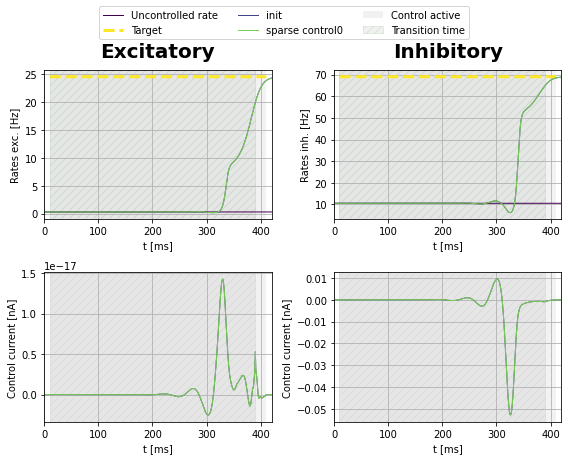

5
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


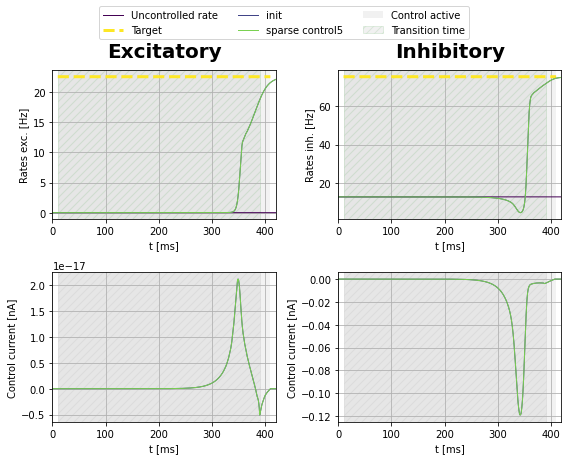

10
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


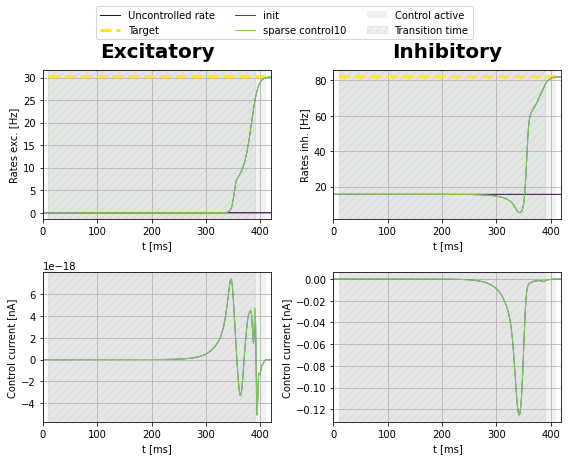

15
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


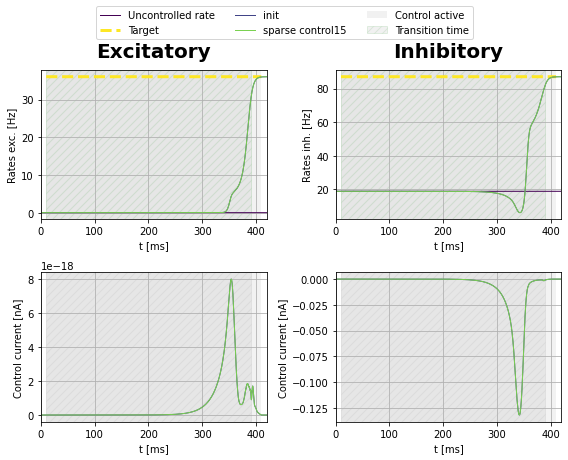

20
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


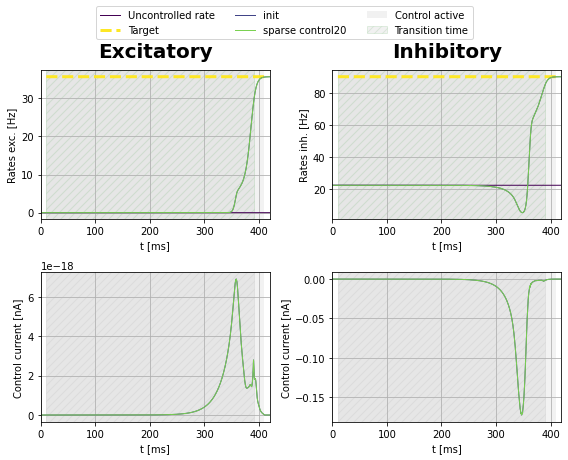

25
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


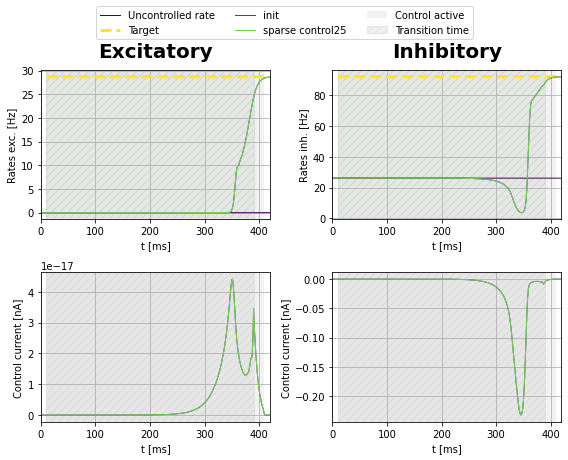

30
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


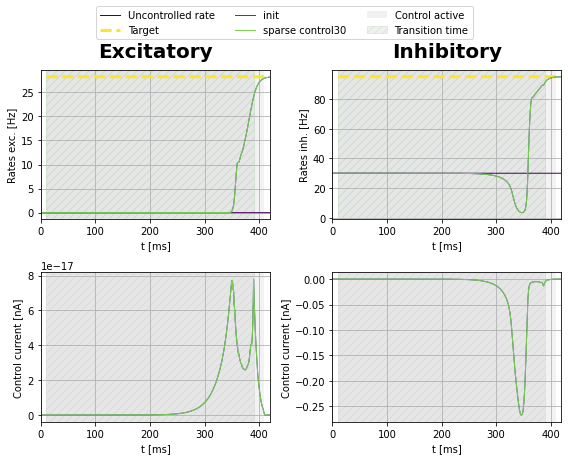

35
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


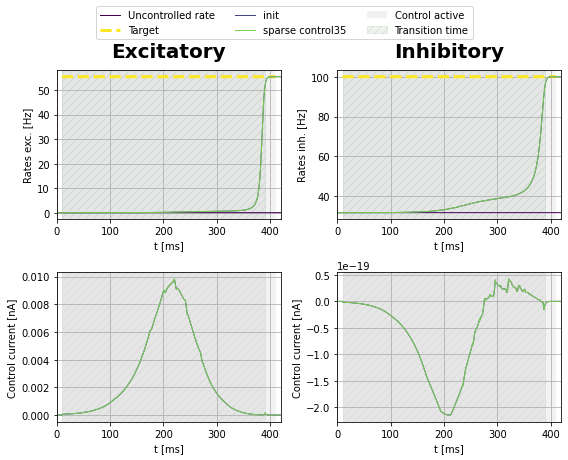

40
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


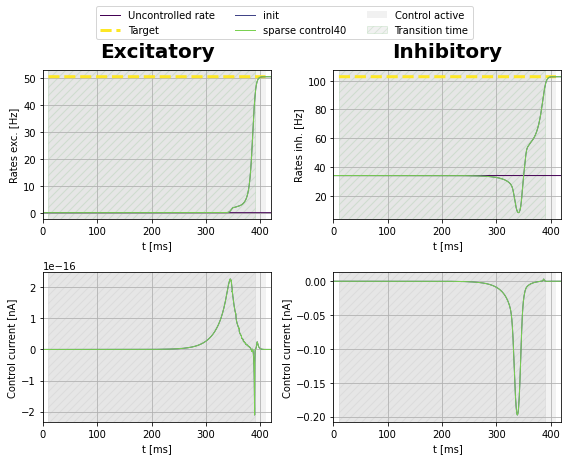

45
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


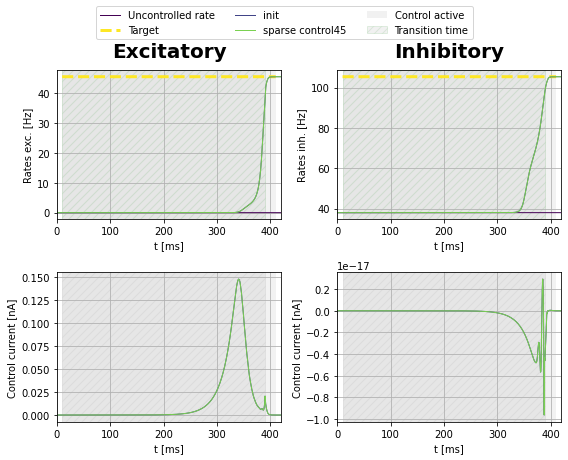

50
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


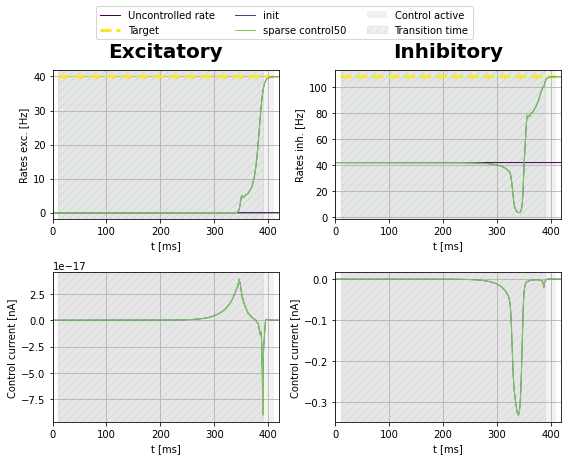

55
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


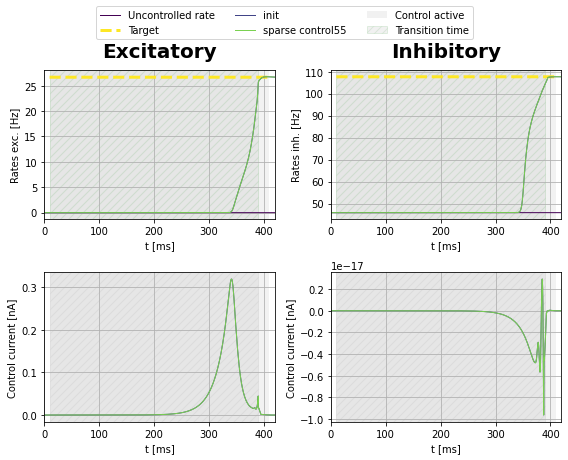

60
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


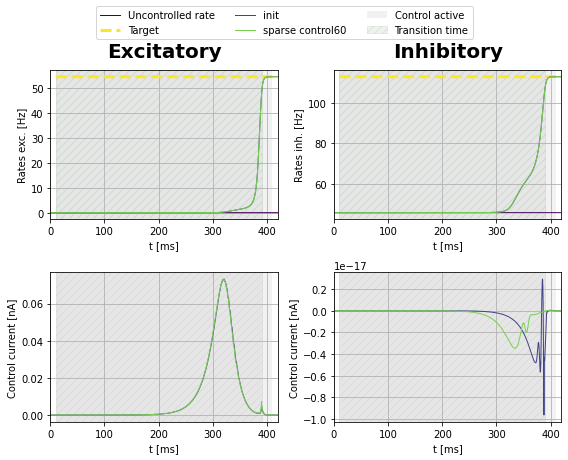

65
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


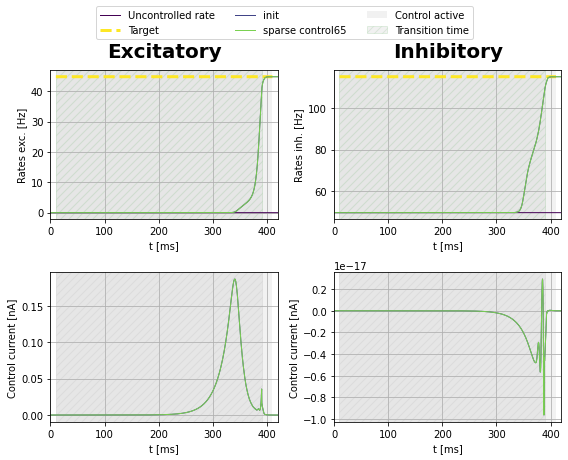

70
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


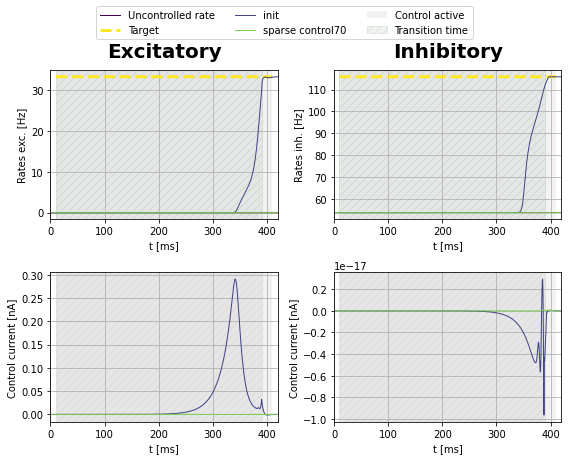

75
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


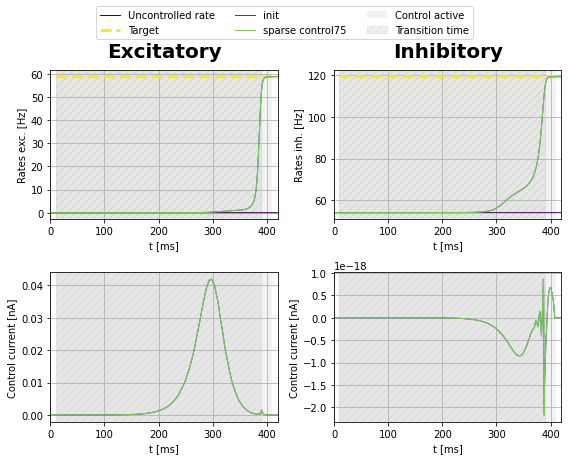

80
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


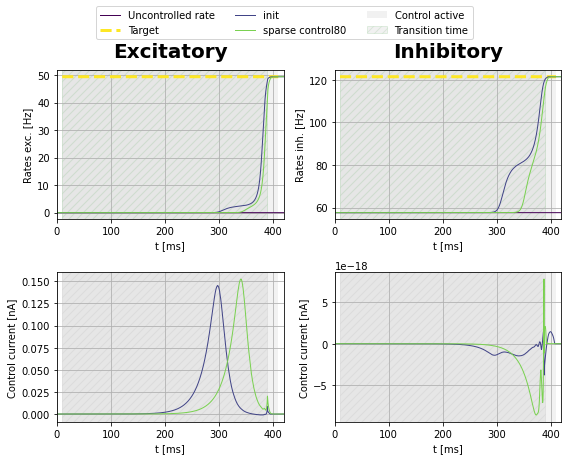

85
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


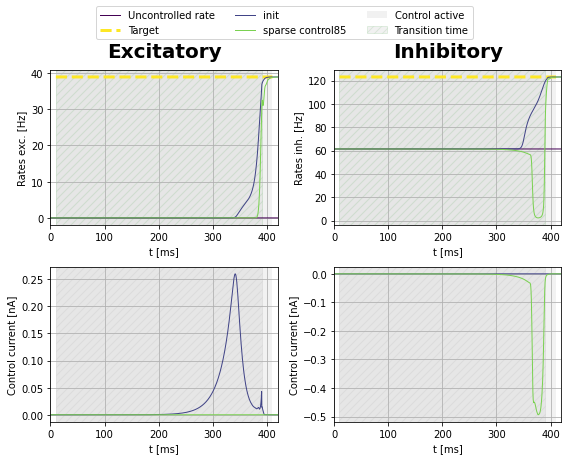

90
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


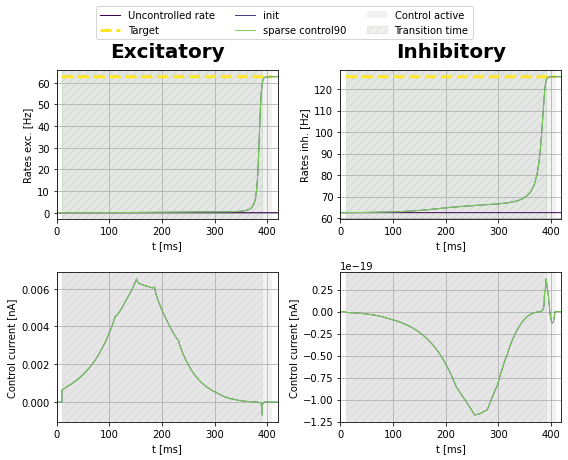

95
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


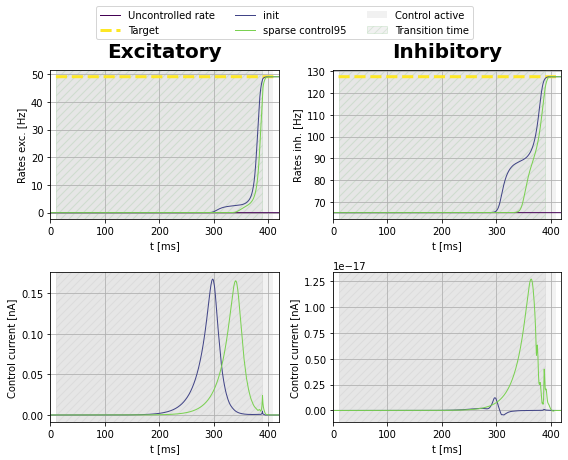

100
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


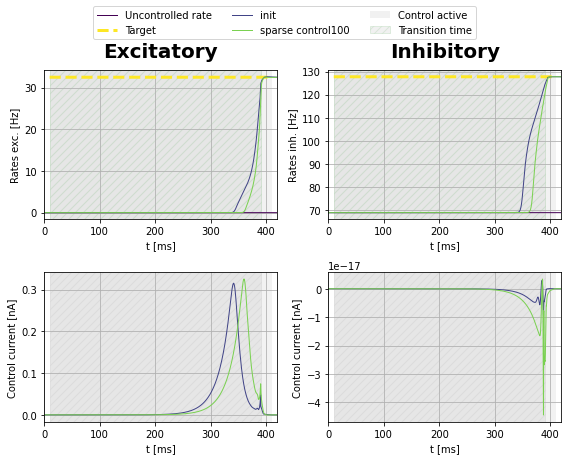

105
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


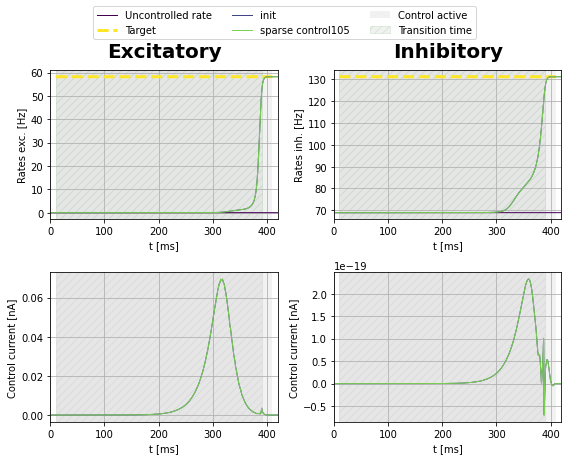

110
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


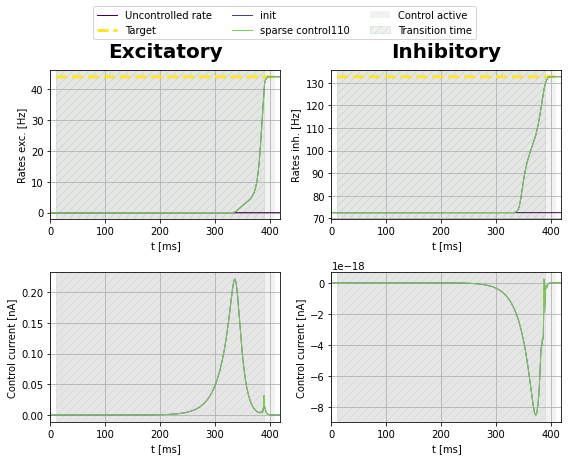

115
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


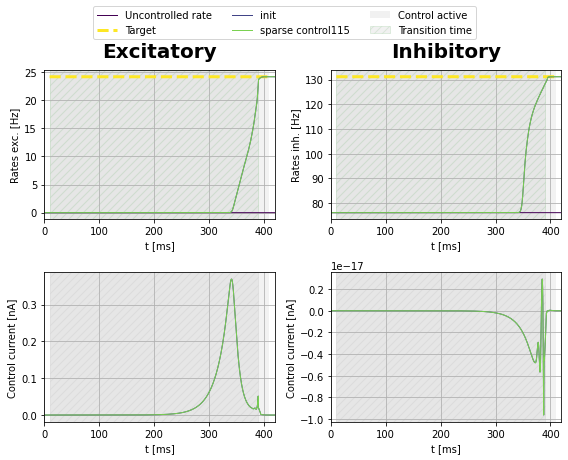

120
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


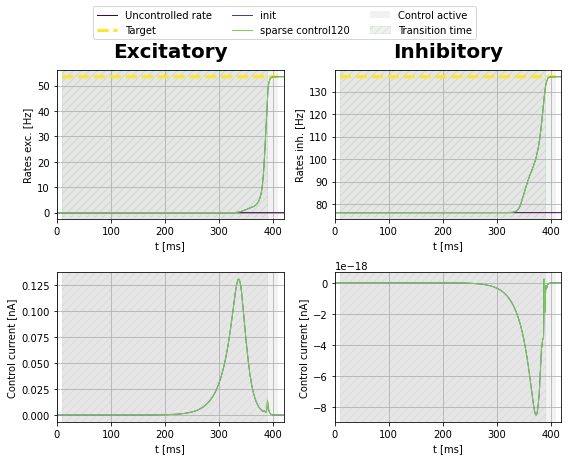

125
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


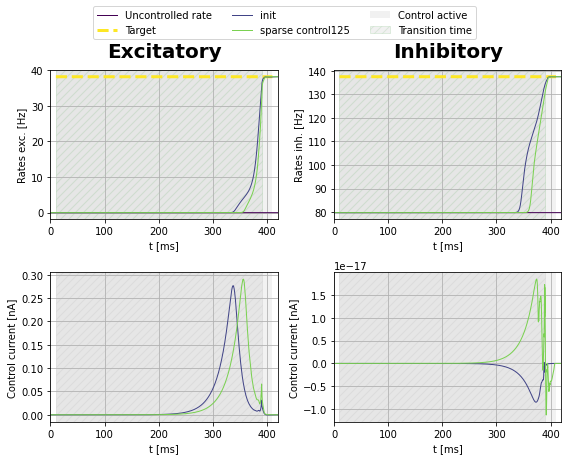

130
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


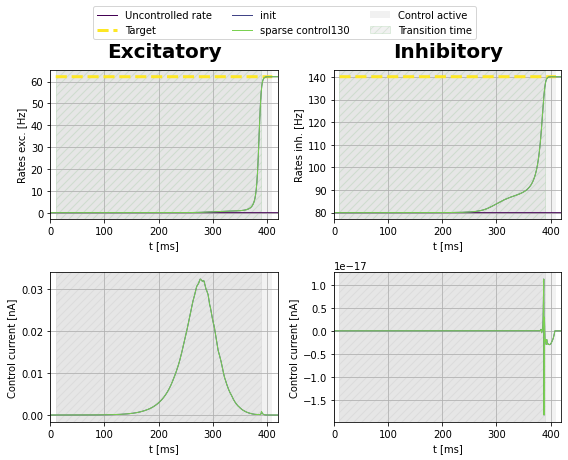

135
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


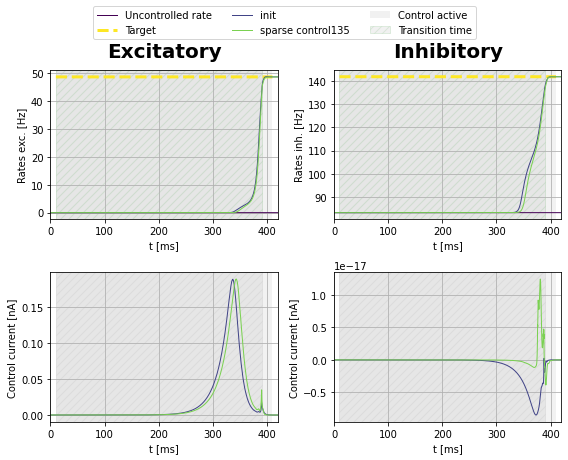

140
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


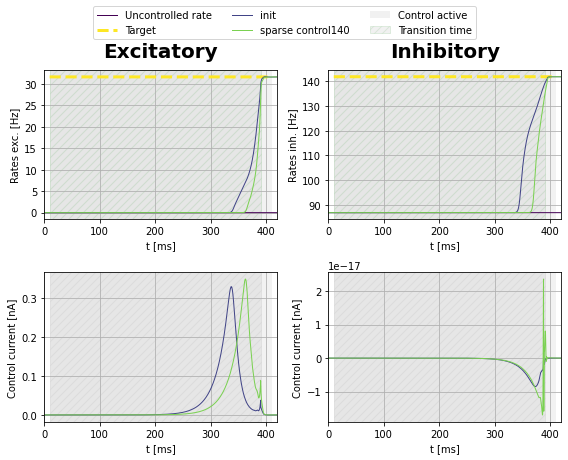

145
------- c_ind 0
(4201,) (4201,)
(4201,) (4201,)
------- c_ind 1
(4201,) (4201,)
(4201,) (4201,)


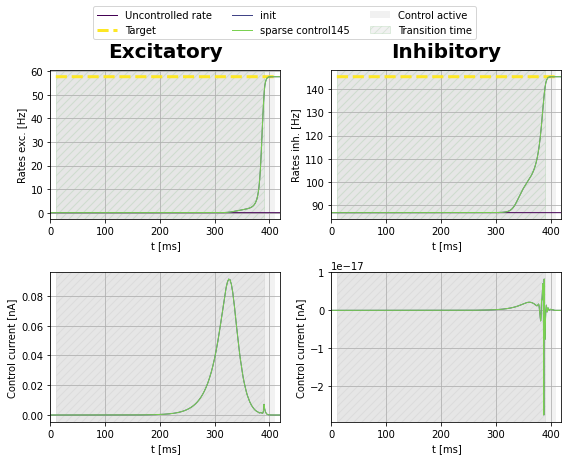

In [20]:

for i in i_range_0:
    
    print(i)
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
    plt.show()


In [21]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

file found


In [ ]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    if counter > 20:
        break
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        
        if conv_1[i] == [True, True]:
            continue
            
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        if not type(bestControl_1[i]) == type(None):
            control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1].copy()
        else:
            control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1].copy()
            cost_1[i] = cost_0[i]
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        with open(final_file_1,'wb') as f:
            pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)
            
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
    counter += 1

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.9936549766804018
Gradient descend method:  None
RUN  1 , total integrated cost =  0.9936549766804018
Control only changes marginally.
RUN  1 , total integrated cost =  0.9936549766804018
Improved over  1  iterations in  1.2605845667421818  seconds by  0.0  percent.
converged for  0
-------  5 0.4000000000000001 0.40000000000000013
set cost params

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  2.4605594318180826
Control only changes marginally.
RUN  1 , total integrated cost =  2.4605594318180826
Improved over  1  iterations in  1.1813248489052057  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62446684010046 -56.62446682182784
converged for  5
-------  10 0.4250000000000001 0.42500000000000016
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.46776616283539
Gradient descend method:  None
RUN  1 , total integrated cost =  2.46776616283539
Control only changes marginally.
RUN  1 , total integrated cost =  2.46776616283539
Improved over  1  iterations in  1.6251219380646944  seconds by  0.0  percent.
converged for  10
-------  15 0.4500000000000001 0.4500000000000002
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.5773994980157227
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  2.5773994980157227
Control only changes marginally.
RUN  1 , total integrated cost =  2.5773994980157227
Improved over  1  iterations in  1.4244078770279884  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67067491750871 -56.67067489825252
converged for  15
-------  20 0.4500000000000001 0.4750000000000002
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.425778651973082
Gradient descend method:  None
RUN  1 , total integrated cost =  3.425778651973082
Control only changes marginally.
RUN  1 , total integrated cost =  3.425778651973082
Improved over  1  iterations in  1.3372178561985493  seconds by  0.0  percent.
converged for  20
-------  25 0.4250000000000001 0.5000000000000002
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8231.907221468136
Gradient descend method:  None
RUN  1 , total integrated cost =  8231.907221

...

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  2.5773994980157227
Control only changes marginally.
RUN  1 , total integrated cost =  2.5773994980157227
Improved over  1  iterations in  1.2894421946257353  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67067491750871 -56.67067489825252
converged for  15
-------  20 0.4500000000000001 0.4750000000000002
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.425778651973082
Gradient descend method:  None
RUN  1 , total integrated cost =  3.425778651973082
Control only changes marginally.
RUN  1 , total integrated cost =  3.425778651973082
Improved over  1  iterations in  1.3349746502935886  seconds by  0.0  percent.
converged for  20
-------  25 0.4250000000000001 0.5000000000000002
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8231.907221468136
Gradient descend method:  None
RUN  1 , total integrated cost =  8231.907221

RUN  1100 , total integrated cost =  3.8913230571687465
RUN  1200 , total integrated cost =  3.8913178848683816
RUN  1300 , total integrated cost =  3.891312604320825
RUN  1400 , total integrated cost =  3.8913072584894124
RUN  1500 , total integrated cost =  3.891302080393541
RUN  1600 , total integrated cost =  3.8912968293940686
RUN  1700 , total integrated cost =  3.8912916198128578
RUN  1800 , total integrated cost =  3.8912863465919654
RUN  1900 , total integrated cost =  3.891280959358981
RUN  2000 , total integrated cost =  3.8912756461594795
RUN  3000 , total integrated cost =  3.891222321036519
RUN  4000 , total integrated cost =  3.891168106807993
RUN  5000 , total integrated cost =  3.8910801025896524
RUN  6000 , total integrated cost =  3.890997282512041
RUN  7000 , total integrated cost =  3.8909493319968376
RUN  8000 , total integrated cost =  3.890428970350867
RUN  9000 , total integrated cost =  3.89037004676311
RUN  10000 , total integrated cost =  3.890144688997849
R

RUN  1 , total integrated cost =  3.8901446415305334
RUN  2 , total integrated cost =  3.890144622118856
RUN  3 , total integrated cost =  3.890144521204447
RUN  4 , total integrated cost =  3.8901444897697224
RUN  5 , total integrated cost =  3.8901444720602734
RUN  6 , total integrated cost =  3.890144366838084
RUN  7 , total integrated cost =  3.8901443339341713
RUN  8 , total integrated cost =  3.890144316864473
RUN  9 , total integrated cost =  3.89014421255708
RUN  10 , total integrated cost =  3.8901441781046313
RUN  11 , total integrated cost =  3.8901441616894905
RUN  12 , total integrated cost =  3.8901440479631524
RUN  13 , total integrated cost =  3.890144000655756
RUN  14 , total integrated cost =  3.890143981196121
RUN  15 , total integrated cost =  3.8901438838654663
RUN  16 , total integrated cost =  3.8901438532082038
RUN  17 , total integrated cost =  3.890143835131684
RUN  18 , total integrated cost =  3.890143735638687
RUN  19 , total integrated cost =  3.8901437014

RUN  1100 , total integrated cost =  3.8889866974880487
RUN  1200 , total integrated cost =  3.888980308549414
RUN  1300 , total integrated cost =  3.888974188458899
RUN  1400 , total integrated cost =  3.8889689030179078
RUN  1500 , total integrated cost =  3.888963219466883
RUN  1600 , total integrated cost =  3.8889574637619813
RUN  1700 , total integrated cost =  3.888951851822446
RUN  1800 , total integrated cost =  3.888946117768338
RUN  1900 , total integrated cost =  3.8889398072951455
RUN  2000 , total integrated cost =  3.888933294896311
RUN  3000 , total integrated cost =  3.888868744020492
RUN  4000 , total integrated cost =  3.8887888959905523
RUN  5000 , total integrated cost =  3.8886182468189214
RUN  6000 , total integrated cost =  3.8885307162537313
RUN  7000 , total integrated cost =  3.888469058871278
RUN  8000 , total integrated cost =  3.8884170699058047
RUN  9000 , total integrated cost =  3.888290792668175
RUN  10000 , total integrated cost =  3.8877967133649074
